# Using a Pre-trained ViT for Image Classification 

In [3]:
from utils.sample_images import visualize, get_subset
from models.vit_small_patch16_224 import build_vit
from config import DEVICE
import torch

/root/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


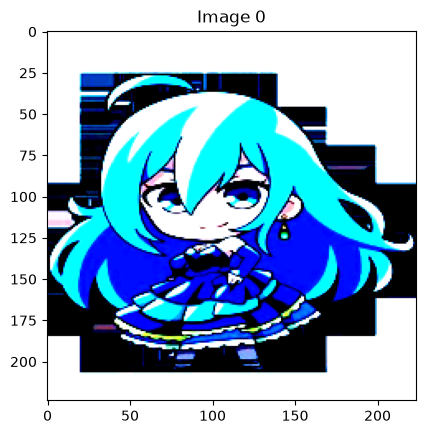

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.1632845].


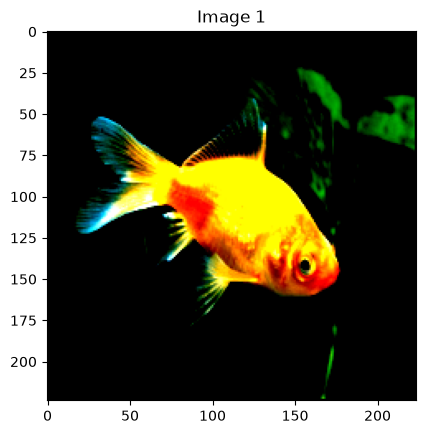

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.535425].


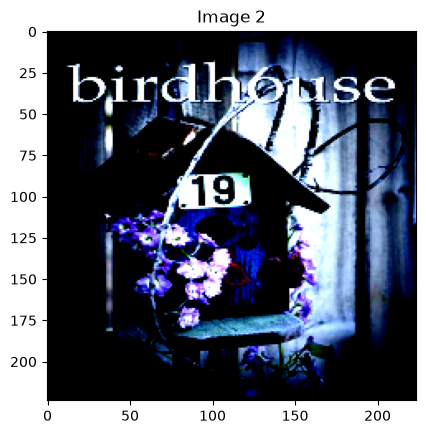

In [4]:
model = build_vit()
model.to(DEVICE)
model.eval()
dataset = get_subset()
visualize()

images = torch.stack([img for img, label in dataset]).to(DEVICE)


with torch.no_grad():
    output = model(images) 

top1_indices = output.argmax(dim=1) 

In [7]:
import json

with open("imagenet-simple-labels.json") as f:
    labels = json.load(f)

for i, idx in enumerate(top1_indices):
    print(f"Image {i}: {labels[idx.item()]}")

Image 0: printer
Image 1: goldfish
Image 2: birdhouse
